## Requirements

In [50]:
import time
import cv2
import numpy as np
from ultralytics import YOLO
import matplotlib.pyplot as plt

## 1-Load trained model

In [51]:
model = YOLO("runs/pose/train/weights/best.pt")

## 2-Extract Points

In [52]:
def extract_points(model, image_path: str):
    # Run model
    results = model(image_path)
    keypoints = results[0].keypoints.xy.cpu().numpy()

    # Wire Points Extraction
    points1 = keypoints[0][0]
    points2 = keypoints[0][1]

    # Axis Points Extraction
    points3 = keypoints[1][0]
    points4 = keypoints[1][1]

    return {'Wire': [points1, points2], 'Axis': [points3, points4]}


image 1/1 D:\Computer Vision\Projects\industrial-pose-estimation\test\4.jpg: 640x640 1 Axis, 1 Wire, 130.8ms
Speed: 5.4ms preprocess, 130.8ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 D:\Computer Vision\Projects\industrial-pose-estimation\test\5.jpg: 640x640 1 Axis, 1 Wire, 11.4ms
Speed: 2.3ms preprocess, 11.4ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 D:\Computer Vision\Projects\industrial-pose-estimation\test\6.jpg: 640x640 1 Axis, 1 Wire, 13.5ms
Speed: 2.0ms preprocess, 13.5ms inference, 2.3ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 D:\Computer Vision\Projects\industrial-pose-estimation\test\7.jpg: 640x640 1 Axis, 1 Wire, 11.4ms
Speed: 2.6ms preprocess, 11.4ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 D:\Computer Vision\Projects\industrial-pose-estimation\test\8.jpg: 640x640 1 Axis, 1 Wire, 11.6ms
Speed: 2.5ms preprocess, 11.6ms inference, 1.7ms postprocess per 

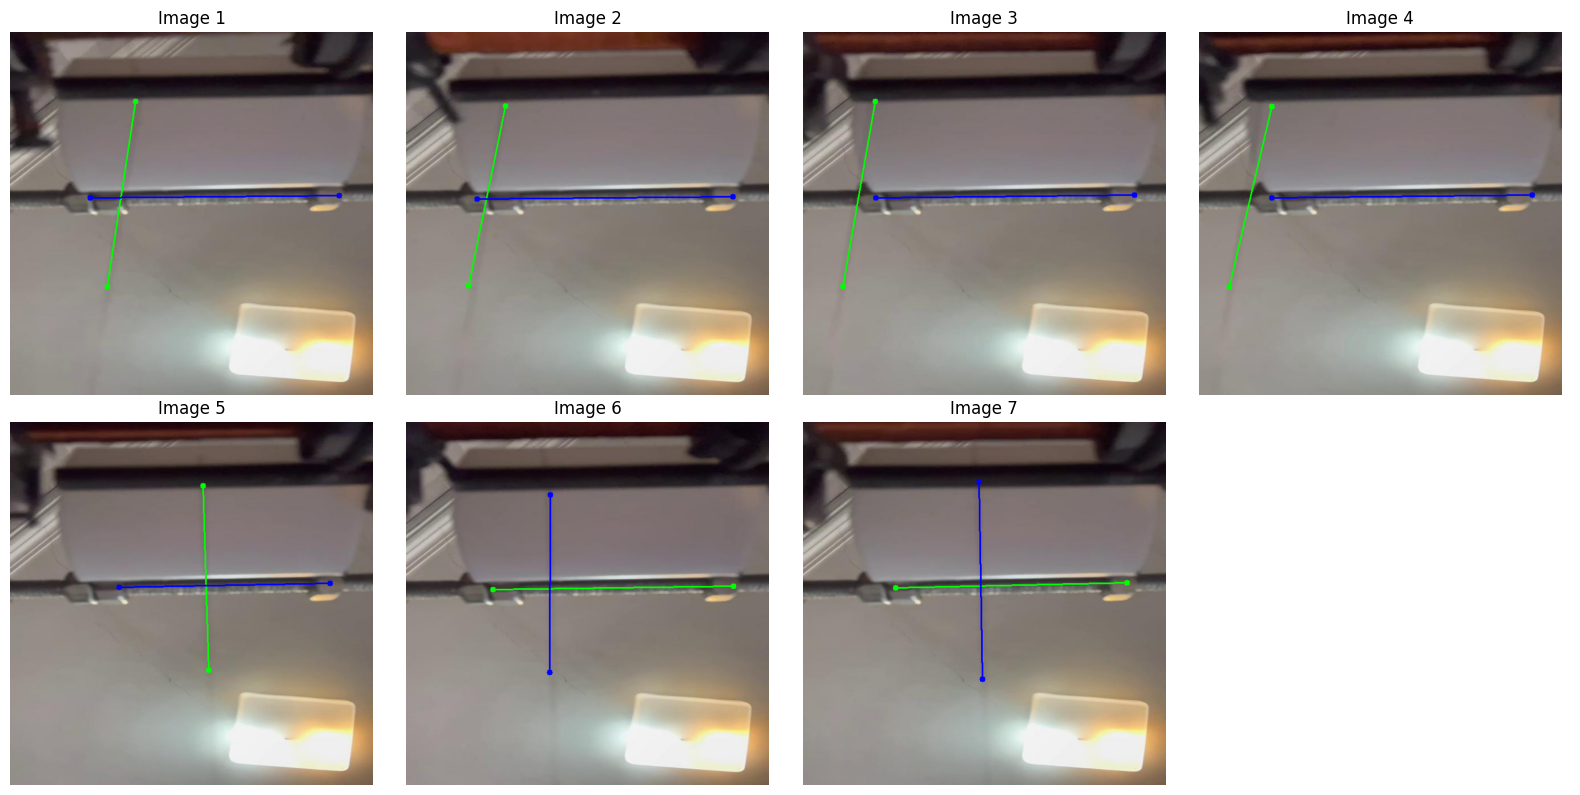

In [53]:
test_images = ["test/4.jpg", "test/5.jpg", "test/6.jpg", "test/7.jpg", "test/8.jpg", "test/9.jpg", "test/10.jpg"]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, image_path in enumerate(test_images):

    img = cv2.imread(image_path)
    points = extract_points(model, image_path)

    # Wire
    x10, y11 = points['Wire'][0]
    x20, y21 = points['Wire'][1]

    cv2.line(img, (int(x10), int(y11)), (int(x20), int(y21)), (0,255,0), 2)
    cv2.circle(img, (int(x10), int(y11)), 5, (0,255,0), -1)
    cv2.circle(img, (int(x20), int(y21)), 5, (0,255,0), -1)

    # Axis
    x30, y31 = points['Axis'][0]
    x40, y41 = points['Axis'][1]

    cv2.line(img, (int(x30), int(y31)), (int(x40), int(y41)), (255,0,0), 2)
    cv2.circle(img, (int(x30), int(y31)), 5, (255,0,0), -1)
    cv2.circle(img, (int(x40), int(y41)), 5, (255,0,0), -1)

    # Convert BGR2RGB for matplotlib
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    axes[i].imshow(img)
    axes[i].set_title(f"Image {i+1}")
    axes[i].axis("off")


axes[-1].axis("off")
plt.tight_layout()
plt.show()

## 3-Calculate Angle

In [54]:
def angle_between_lines(line1, line2):
    p1, p2 = line1
    p3, p4 = line2

    v1 = np.array([p2[0]-p1[0], p2[1]-p1[1]])
    v2 = np.array([p4[0]-p3[0], p4[1]-p3[1]])

    v1 = v1 / np.linalg.norm(v1)
    v2 = v2 / np.linalg.norm(v2)

    cos_theta = np.dot(v1, v2)
    cos_theta = np.clip(cos_theta, -1, 1)
    angle = np.arccos(cos_theta)

    return np.degrees(angle)


image 1/1 D:\Computer Vision\Projects\industrial-pose-estimation\test\4.jpg: 640x640 1 Axis, 1 Wire, 141.8ms
Speed: 5.3ms preprocess, 141.8ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 D:\Computer Vision\Projects\industrial-pose-estimation\test\5.jpg: 640x640 1 Axis, 1 Wire, 78.9ms
Speed: 5.4ms preprocess, 78.9ms inference, 3.1ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 D:\Computer Vision\Projects\industrial-pose-estimation\test\6.jpg: 640x640 1 Axis, 1 Wire, 14.0ms
Speed: 2.0ms preprocess, 14.0ms inference, 2.8ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 D:\Computer Vision\Projects\industrial-pose-estimation\test\7.jpg: 640x640 1 Axis, 1 Wire, 11.6ms
Speed: 2.2ms preprocess, 11.6ms inference, 2.3ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 D:\Computer Vision\Projects\industrial-pose-estimation\test\8.jpg: 640x640 1 Axis, 1 Wire, 15.2ms
Speed: 2.1ms preprocess, 15.2ms inference, 2.9ms postprocess per 

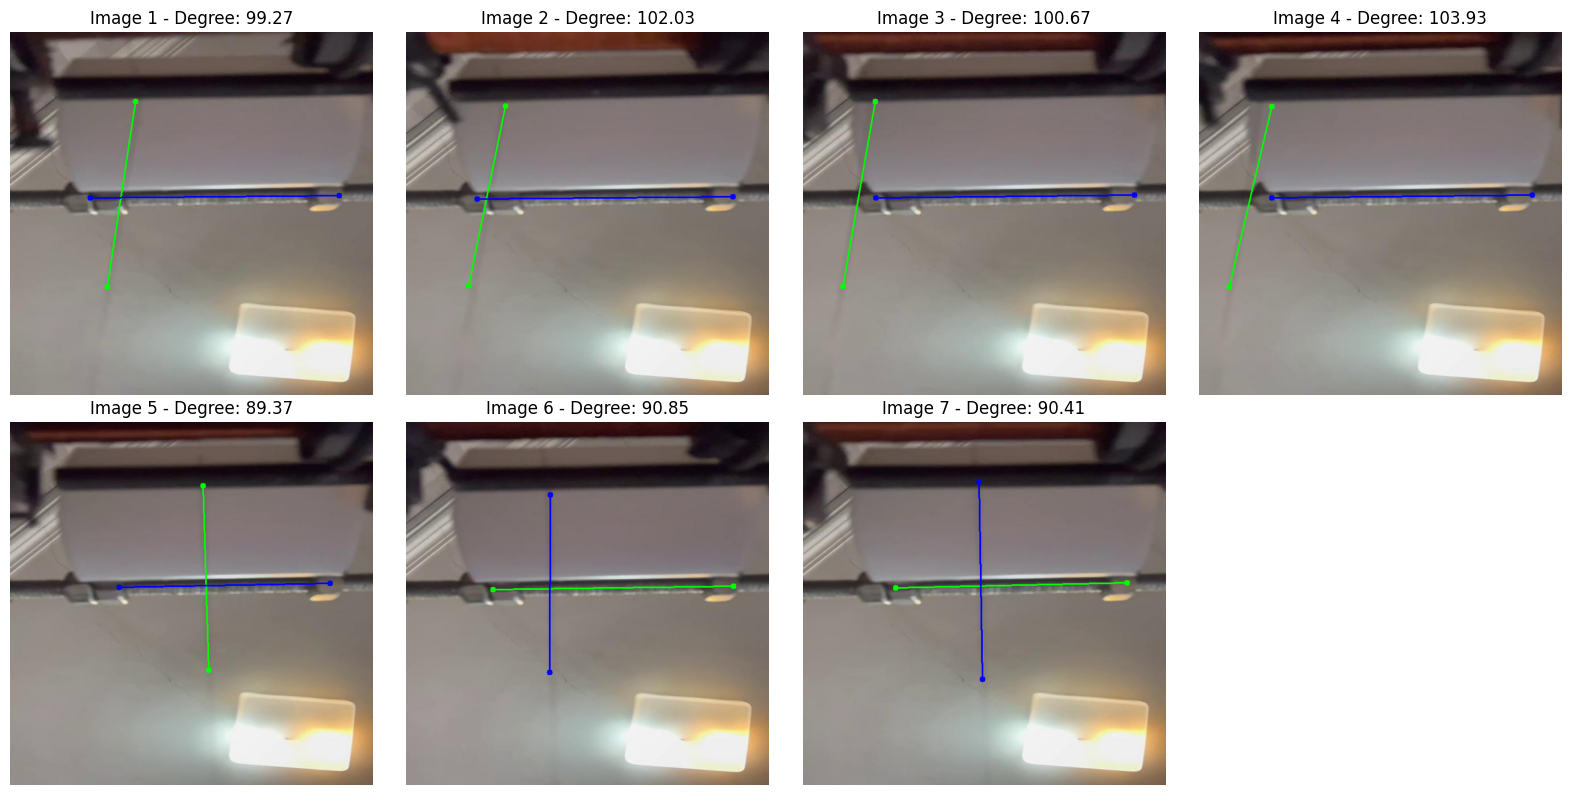

In [58]:
test_images = ["test/4.jpg", "test/5.jpg", "test/6.jpg", "test/7.jpg", "test/8.jpg", "test/9.jpg", "test/10.jpg"]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, image_path in enumerate(test_images):

    img = cv2.imread(image_path)
    points = extract_points(model, image_path)

    # Wire
    x10, y11 = points['Wire'][0]
    x20, y21 = points['Wire'][1]

    cv2.line(img, (int(x10), int(y11)), (int(x20), int(y21)), (0,255,0), 2)
    cv2.circle(img, (int(x10), int(y11)), 5, (0,255,0), -1)
    cv2.circle(img, (int(x20), int(y21)), 5, (0,255,0), -1)


    # Axis
    x30, y31 = points['Axis'][0]
    x40, y41 = points['Axis'][1]

    wire_line = (points['Wire'][0], points['Wire'][1])
    axis_line = (points['Axis'][0], points['Axis'][1])
    angle = angle_between_lines(wire_line, axis_line)

    cv2.line(img, (int(x30), int(y31)), (int(x40), int(y41)), (255,0,0), 2)
    cv2.circle(img, (int(x30), int(y31)), 5, (255,0,0), -1)
    cv2.circle(img, (int(x40), int(y41)), 5, (255,0,0), -1)

    # Convert BGR2RGB for matplotlib
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    axes[i].imshow(img)
    axes[i].set_title(f"Image {i+1} - Degree: {angle:.2f}")
    axes[i].axis("off")


axes[-1].axis("off")
plt.tight_layout()
plt.show()

## 4-Check Inference Time

In [61]:
def extract_points(model, image_path: str):
    # Run model
    start = time.time()
    results = model(image_path)
    keypoints = results[0].keypoints.xy.cpu().numpy()
    end = time.time()

    # Wire Points Extraction
    points1 = keypoints[0][0]
    points2 = keypoints[0][1]

    # Axis Points Extraction
    points3 = keypoints[1][0]
    points4 = keypoints[1][1]

    exe_time = end - start
    return {'Wire': [points1, points2], 'Axis': [points3, points4]}, exe_time


test_images = ["test/4.jpg", "test/5.jpg", "test/6.jpg", "test/7.jpg", "test/8.jpg", "test/9.jpg", "test/10.jpg"]
for path in test_images:
    print(f"Inference Time: {extract_points(model, path)[1]}")


image 1/1 D:\Computer Vision\Projects\industrial-pose-estimation\test\4.jpg: 640x640 1 Axis, 1 Wire, 142.4ms
Speed: 5.6ms preprocess, 142.4ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 640)
Inference Time: 0.1578660011291504

image 1/1 D:\Computer Vision\Projects\industrial-pose-estimation\test\5.jpg: 640x640 1 Axis, 1 Wire, 79.1ms
Speed: 5.0ms preprocess, 79.1ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)
Inference Time: 0.09028148651123047

image 1/1 D:\Computer Vision\Projects\industrial-pose-estimation\test\6.jpg: 640x640 1 Axis, 1 Wire, 11.3ms
Speed: 1.8ms preprocess, 11.3ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)
Inference Time: 0.018985986709594727

image 1/1 D:\Computer Vision\Projects\industrial-pose-estimation\test\7.jpg: 640x640 1 Axis, 1 Wire, 11.4ms
Speed: 1.7ms preprocess, 11.4ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)
Inference Time: 0.02002692222595215

image 1/1 D:\Computer Vision\